# **종합실습2 이변량분석(y-범주) : 직원 이직 분석**

![](https://www.talentalign.com/wp-content/uploads/2019/09/main-qimg-2434943004743f79c0abf540cb4f6e2c-cropped.jpg)

* 직원 이직 분석
    * 회사에서 최근 1~2년 사이 이직률이 상승하였습니다.
    * 여러분은, 직원들이 이직하는데 중요한 요인이 무엇인지 데이터를 기반으로 한 분석을 의뢰 받았습니다.

## **1.환경준비**

* 라이브러리 불러오기

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic      #mosaic plot!

import scipy.stats as spst

* 데이터 불러오기 : 다음의 예제 데이터를 사용합니다.

In [7]:
# 직원 이직 데이터
# 2023년 12월 기준부터 지금까지 이직을 했는지 안 했는지?
# 행의 의미 = 직원 한 사람마다의 정보
# 시계열 데이터 X (순서가 없다.)
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/Attrition_simple3.csv'
data = pd.read_csv(path)
data.head(5)

,Attrition,Age,DistanceFromHome,EmployeeNumber,Gender,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,TotalWorkingYears
0,0,27,2,1898,Female,3,Single,6500,No,14,9
1,0,27,9,1965,Male,4,Single,4105,No,14,7
2,0,44,2,1703,Female,4,Married,7879,Yes,19,9
3,0,42,2,1231,Male,1,Married,6272,No,16,10
4,0,32,1,2016,Female,4,Married,10422,No,19,14


> * 변수설명
    * **Attrition**	:	이직여부, Yes , No (**Target**)
    * **Age**	:	나이
    * **DistanceFromHome**	:	집-직장 거리(마일)
    * **EmployeeNumber**	:	사번
    * **Gender**	:	성별(Male, Female)
    * **JobSatisfaction**	:	직무 만족도, 다음시트 참조
    * **MaritalStatus**	:	결혼상태(Married, Single, Divorced)
    * **MonthlyIncome**	:	월급(달러)
    * **OverTime**	:	야근여부
    * **PercentSalaryHike**	:	전년대비 급여인상율(%)
    * **TotalWorkingYears**	:	총 근무 연수



## **2.범주-->범주**

In [163]:
target = 'Attrition'  # 이직여부

### **(1) Gender --> Attrition**

In [166]:
feature = 'Gender'

* 교차표

In [169]:
# 두 범주별 빈도수를 교차표로 만들어 봅시다.
pd.crosstab(data[target], data[feature])

Gender,Female,Male
Attrition,,
0,157,248
1,66,129


In [171]:
pd.crosstab(data[target], data[feature], normalize = 'columns')

Gender,Female,Male
Attrition,,
0,0.704036,0.657825
1,0.295964,0.342175


* 시각화
* 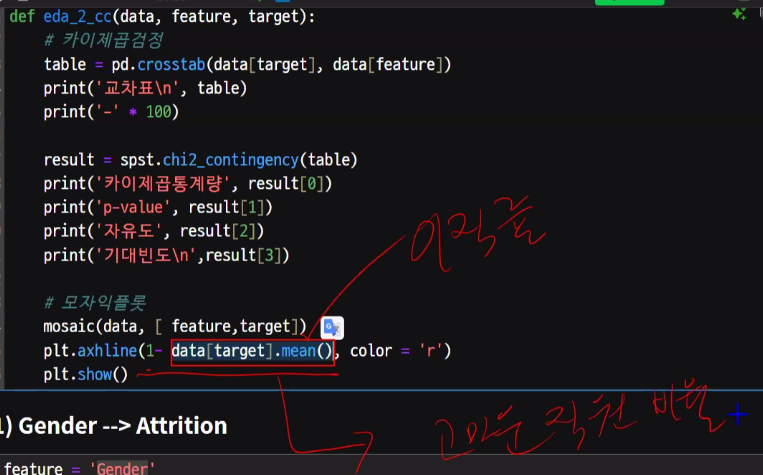

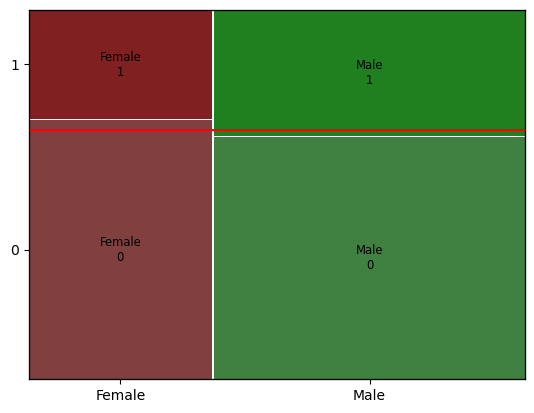

In [125]:
# 차이가 있긴 있다.
# 여자 직원은 이직률이 조금 낮다.

mosaic(data, [ feature,target])
plt.axhline(1- data[target].mean(), color = 'r')
plt.show()

* 수치화 : 카이제곱검정

In [128]:
# 먼저 집계
table = pd.crosstab(data[target], data[feature])
print('교차표\n', table)
print('-' * 100)

# 카이제곱검정
result = spst.chi2_contingency(table)
print('카이제곱통계량', result[0])
print('p-value', result[1])
print('자유도', result[2])
print('기대빈도\n',result[3])

교차표
 Gender     Female  Male
Attrition              
0             157   248
1              66   129
----------------------------------------------------------------------------------------------------
카이제곱통계량 1.1614318259891623
p-value 0.28116879016055174
자유도 1
기대빈도
 [[150.525 254.475]
 [ 72.475 122.525]]


* 파악된 내용을 기술해 봅시다.

In [131]:
# (차이가 크다 = 관련이 있다)
# (카이제곱이 클수록 기대빈도로부터 실제 값에 차이가 크다. , 자유도의 약 2배 보다 크면, 차이가 있다고 본다.)

# 카이제곱검정으로는 관련이 없다고 나오나(자유도의 2배보다 크지 않기 때문에), 그래프로 볼때 약간 관련이 있다고 판단됨.
# pv를 보면 차이가 없다는 사실을 알 수 있다. -> 성별은 이직여부에 별로 관련이 없다.(성별은 이직여부에 별로 차이가 없다.)

### **(2) JobSatisfaction --> Attrition**

In [173]:
feature = 'JobSatisfaction'  # 직무 만족도

* 교차표

In [176]:
# 두 범주별 빈도수를 교차표로 만들어 봅시다.
pd.crosstab(data[target], data[feature])

JobSatisfaction,1,2,3,4
Attrition,,,,
0,74,79,114,138
1,52,37,59,47


In [178]:
pd.crosstab(data[target], data[feature], normalize = 'columns')

JobSatisfaction,1,2,3,4
Attrition,,,,
0,0.587302,0.681034,0.65896,0.745946
1,0.412698,0.318966,0.34104,0.254054


* 시각화

In [181]:
# temp = data.sort_values('JobSatisfaction')

# mosaic(temp, [ 'JobSatisfaction', target])
# plt.axhline(1- data[target].mean(), color = 'r')
# plt.show()

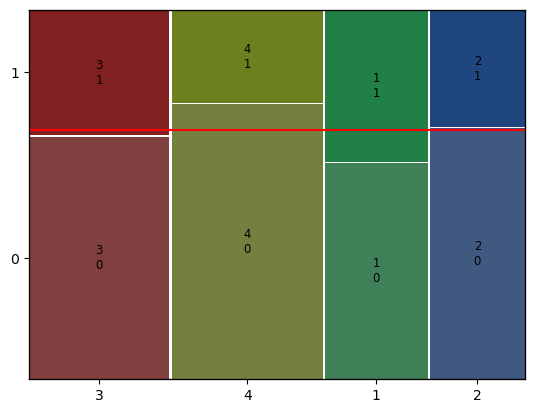

In [183]:

mosaic(data, [ feature,target])
plt.axhline(1- data[target].mean(), color = 'r')
plt.show()

* 수치화 : 카이제곱검정

In [187]:
# 먼저 집계
table = pd.crosstab(data[target], data[feature])
print('교차표\n', table)
print('-' * 100)

# 카이제곱검정
result = spst.chi2_contingency(table)
print('카이제곱통계량', result[0])
print('p-value', result[1])
print('자유도', result[2])
print('기대빈도\n',result[3])

교차표
 JobSatisfaction   1   2    3    4
Attrition                        
0                74  79  114  138
1                52  37   59   47
----------------------------------------------------------------------------------------------------
카이제곱통계량 8.884191097554549
p-value 0.03087092125625072
자유도 3
기대빈도
 [[ 85.05   78.3   116.775 124.875]
 [ 40.95   37.7    56.225  60.125]]


* 파악된 내용을 기술해 봅시다.

그래프를 보면 1(불만)은 이직률이 높고, 4(매우만족)은 이직률이 낮다. + 2는 평균과 차이가 거의 없다.    
-> 직무 만족도를 높일 수 있는 요인을 찾아서 이직률을 낮춰야 한다.    


In [150]:
# 그래프를 보면 차이가 약간 있어보인다.
# 카이제곱검정으로 보면 카이제곱통계량이 자유도의 두배이상이기 때문에 차이가 있다고 볼 수 있다.
# pv를 보면 0.05보다 작으므로 유의하다.
# 따라서, 직무 만족도(JobSatisfaction)는 Attrition와 관련이 있다!! (차이가 있다=관련이 있다)

### **(3) MaritalStatus --> Attrition**

In [189]:
feature = 'MaritalStatus'  # 결혼 상태

* 교차표

In [192]:
# 두 범주별 빈도수를 교차표로 만들어 봅시다.
pd.crosstab(data[target], data[feature])

MaritalStatus,Divorced,Married,Single
Attrition,,,
0,89,205,111
1,23,69,103


In [194]:
pd.crosstab(data[target], data[feature], normalize = 'columns')

MaritalStatus,Divorced,Married,Single
Attrition,,,
0,0.794643,0.748175,0.518692
1,0.205357,0.251825,0.481308


* 시각화

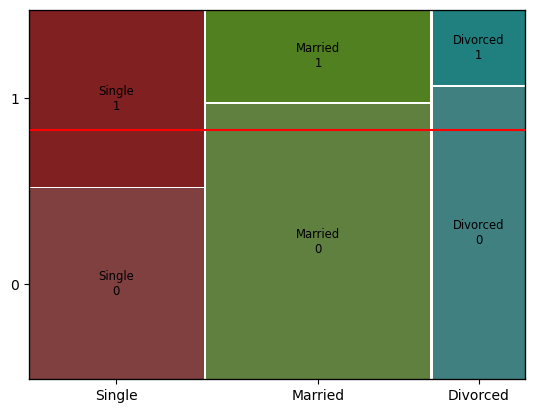

In [197]:

mosaic(data, [ feature,target])
plt.axhline(1- data[target].mean(), color = 'r')
plt.show()

* 수치화 : 카이제곱검정

In [199]:
# 먼저 집계
table = pd.crosstab(data[target], data[feature])
print('교차표\n', table)
print('-' * 100)

# 카이제곱검정
result = spst.chi2_contingency(table)
print('카이제곱통계량', result[0])
print('p-value', result[1])
print('자유도', result[2])
print('기대빈도\n',result[3])

교차표
 MaritalStatus  Divorced  Married  Single
Attrition                               
0                    89      205     111
1                    23       69     103
----------------------------------------------------------------------------------------------------
카이제곱통계량 37.829711907070525
p-value 6.100738829354226e-09
자유도 2
기대빈도
 [[ 75.6  184.95 144.45]
 [ 36.4   89.05  69.55]]


* 파악된 내용을 기술해 봅시다.

그래프를 확인해보면,         
카이제곱통계량이 자유도의 두배 이상으므로 차이가 있다.   

싱글이 이직률이 높다.
이혼은 퇴사율이 높지 않다.

### **(4) OverTime --> Attrition**

In [201]:
feature = 'OverTime'  # 야근여부

* 교차표

In [204]:
# 두 범주별 빈도수를 교차표로 만들어 봅시다.
pd.crosstab(data[target], data[feature])

OverTime,No,Yes
Attrition,,
0,315,90
1,90,105


In [206]:
pd.crosstab(data[target], data[feature], normalize = 'columns')

OverTime,No,Yes
Attrition,,
0,0.777778,0.461538
1,0.222222,0.538462


* 시각화

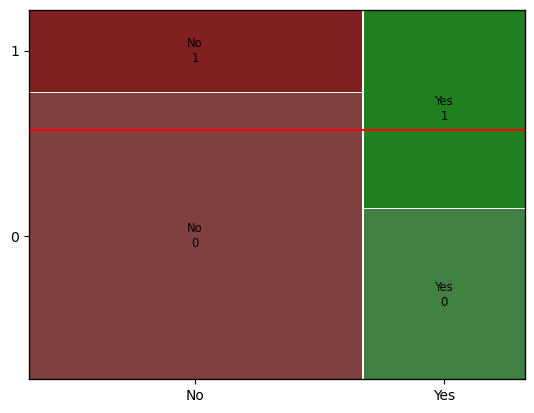

In [209]:

mosaic(data, [ feature,target])
plt.axhline(1- data[target].mean(), color = 'r')
plt.show()

* 수치화 : 카이제곱검정

In [212]:
# 먼저 집계
table = pd.crosstab(data[target], data[feature])
print('교차표\n', table)
print('-' * 100)

# 카이제곱검정
result = spst.chi2_contingency(table)
print('카이제곱통계량', result[0])
print('p-value', result[1])
print('자유도', result[2])
print('기대빈도\n',result[3])

교차표
 OverTime    No  Yes
Attrition          
0          315   90
1           90  105
----------------------------------------------------------------------------------------------------
카이제곱통계량 58.57149427899665
p-value 1.9603625783060702e-14
자유도 1
기대빈도
 [[273.375 131.625]
 [131.625  63.375]]


* 파악된 내용을 기술해 봅시다.

카이제곱통계량이 자유도의 두배이상 높다. -> 차이가 있다.     
야근 여부와 이직률은 관련이 있다.   
야근을 하는 사람이 이직률이 높다.

## **3.숫자-->범주**

### **(1) Age --> Attrition**

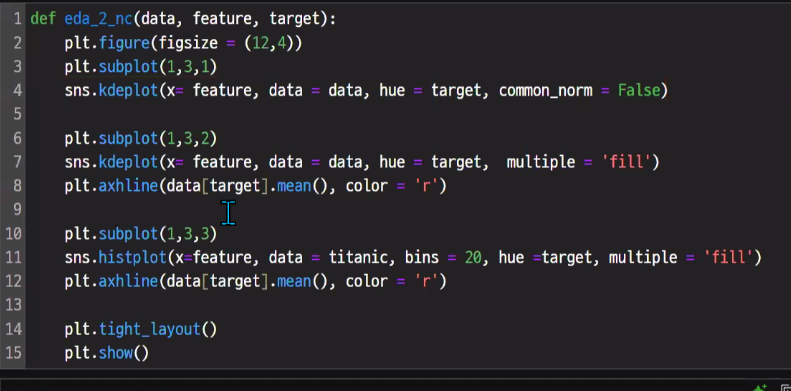

In [25]:
feature = 'Age'

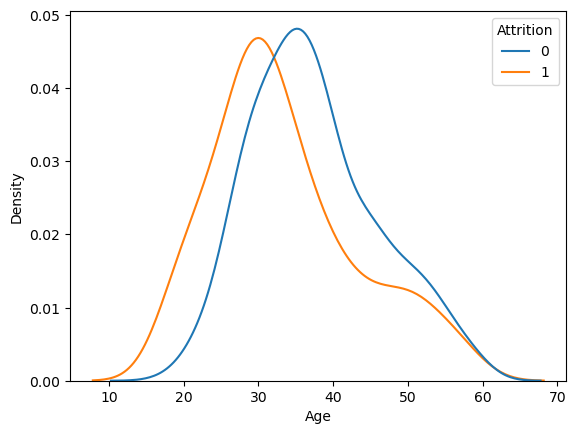

In [27]:
# 32세보다 왼쪽에 있는 사람들은 평균 이직률이 높다(주황색 선이 이직한 사람)

sns.kdeplot(x= feature, data = data, hue = target,
            common_norm = False)
plt.show()

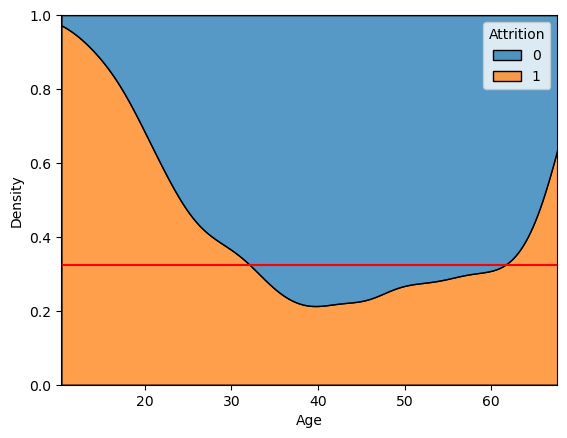

In [28]:
# 32세 이후 사람들은 이직률이 낮다.

sns.kdeplot(x= feature, data = data, hue = target
            , multiple = 'fill')
plt.axhline(data[target].mean(), color = 'r')
plt.show()

* 파악된 내용을 기술해 봅시다.

### **(2) DistanceFromHome --> Attrition**

In [219]:
feature = 'DistanceFromHome'   # 집-직장 거리(마일)

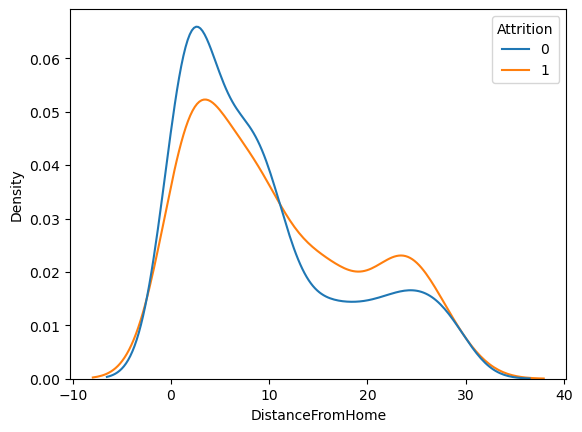

In [221]:

sns.kdeplot(x= feature, data = data, hue = target,
            common_norm = False)
plt.show()

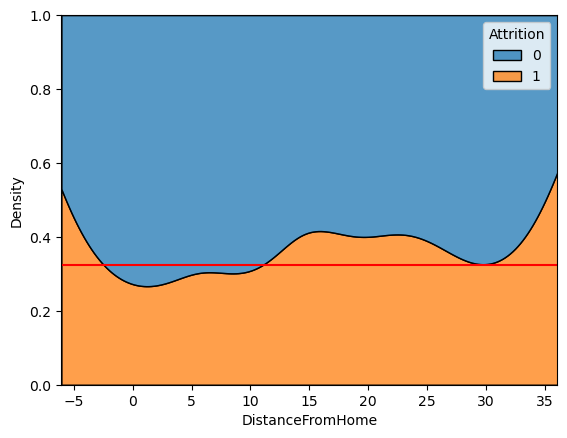

In [223]:
sns.kdeplot(x= feature, data = data, hue = target
            , multiple = 'fill')
plt.axhline(data[target].mean(), color = 'r')
plt.show()

* 파악된 내용을 기술해 봅시다.

In [ ]:
# 회사와 집이 가까운 사람이 이직률이 적다.
# 회사는 기숙사, 통근버스, 월세지원을 제공해주는 방안을 생각해보면 좋을 것이다.

### **(3) MonthlyIncome --> Attrition**

In [225]:
feature = 'MonthlyIncome'  # 월급(달러)

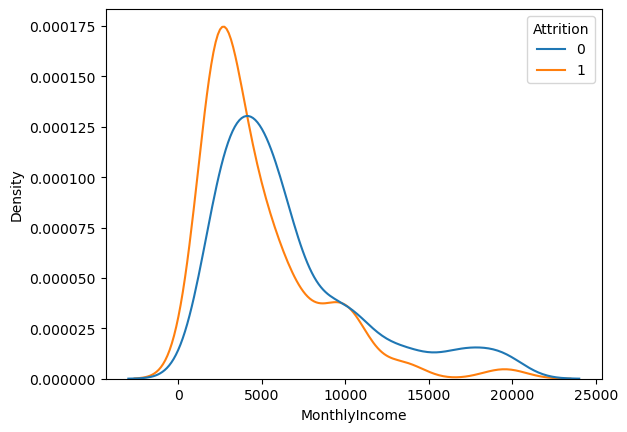

In [227]:

sns.kdeplot(x= feature, data = data, hue = target,
            common_norm = False)
plt.show()

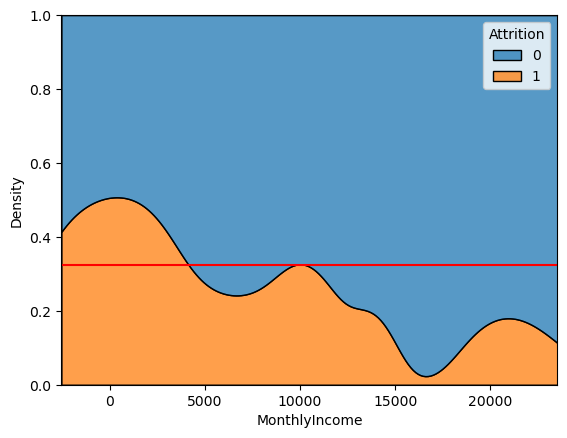

In [228]:
sns.kdeplot(x= feature, data = data, hue = target
            , multiple = 'fill')
plt.axhline(data[target].mean(), color = 'r')
plt.show()

* 파악된 내용을 기술해 봅시다.

In [ ]:
# 월급이 낮을수록 이직률이 높다.
# 특이한 사실!) 월급(10000달러 부분)이 높은데 이직률이 평균과 같은 사람이 있다. -> 2~3년차정도가 이직을 한다. 몸값(직급상승)을 높이기 위해
# 회사는 고임금자일 수 있는 성과를 잘 내는 사람들을 잡는데에 힘을 써야 한다. 해당 사람들을 추가 분석해서 이직을 막아야 한다.

### **(4) PercentSalaryHike --> Attrition**

In [231]:
feature = 'PercentSalaryHike'  # 전년대비 급여인상율(%)

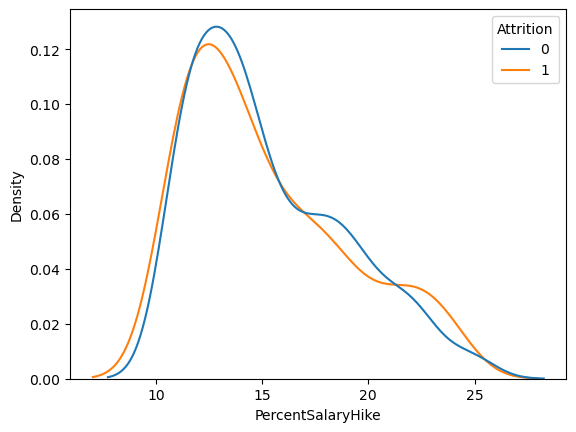

In [233]:

sns.kdeplot(x= feature, data = data, hue = target,
            common_norm = False)
plt.show()

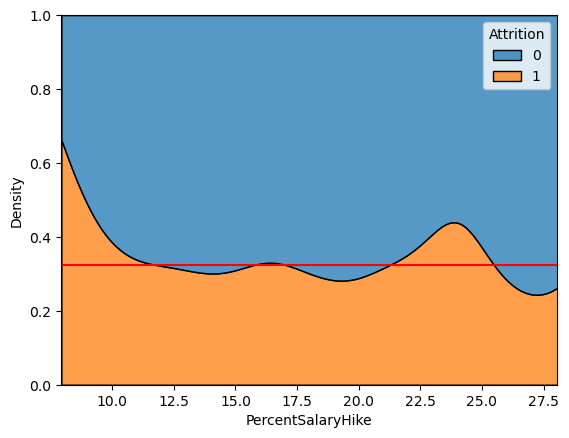

In [234]:
sns.kdeplot(x= feature, data = data, hue = target
            , multiple = 'fill')
plt.axhline(data[target].mean(), color = 'r')
plt.show()

* 파악된 내용을 기술해 봅시다.

In [ ]:
# 급여 인상률은 이직여부에 아주 큰 영향을 주는 것 같지는 않다. 
# 급여 인상률이 완전 높지 않으면 이직을 하지 않는다.(?)
# 급여 인상률이 높아도 이직을 한다. -> 급여 인상률이 이직여부에 큰 영향을 주지 않는듯 보여서 분석을 하기 쉽지 않다.

### **(5) TotalWorkingYears --> Attrition**

In [237]:
feature = 'TotalWorkingYears'  # 총근무 연수

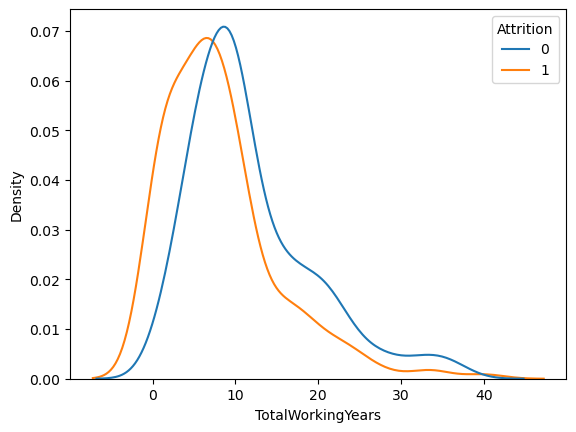

In [239]:

sns.kdeplot(x= feature, data = data, hue = target,
            common_norm = False)
plt.show()

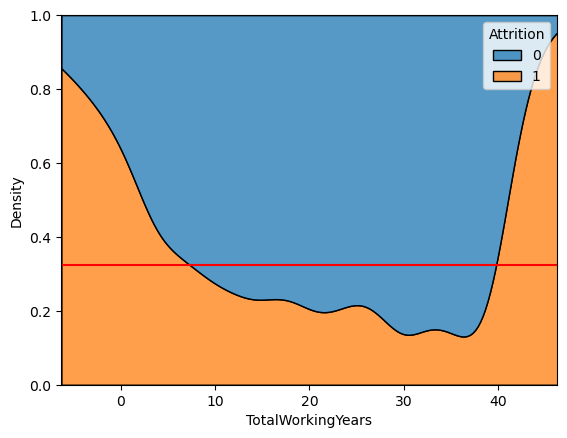

In [240]:
sns.kdeplot(x= feature, data = data, hue = target
            , multiple = 'fill')
plt.axhline(data[target].mean(), color = 'r')
plt.show()

* 파악된 내용을 기술해 봅시다.

In [ ]:
# 총근무 연수가 높을수록 이직을 덜 한다. 
# 아마 나이와도 관련이 있을 듯 싶다.

## **4.관계 정리하기**

① 강한관계

In [ ]:
# Marital(결혼상태), OverTime(야근), Age(TWY)(나이), Distance(거리), MonthlyIncome(월급)

② 중간관계

In [ ]:
# JobSatisfaction(직무만족도), PrecentSH(전년대비 급여인상율)

③ 관계없음(약한 관계)

In [ ]:
# Gender(성별)